# Iran Inflation Rate Analysis (2015–2026)

Data sources and methodology for this notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import wbdata
import datetime

In [2]:
indicator = {'FP.CPI.TOTL.ZG': 'inflation'}

country = ['IRN']

df = wbdata.get_dataframe(indicator, country=country)
df = df.dropna()
df = df.sort_index()
print(df.tail(10))

      inflation
date           
2015  12.484682
2016   7.245425
2017   8.044924
2018  18.014118
2019  39.907346
2020  30.594139
2021  43.389016
2022  43.488464
2023  44.579186
2024  32.455871


In [3]:
extra = pd.DataFrame({
    'inflation': [48.6, 62.2]
}, index=pd.Index(['2025', '2026'], name='date'))

df_full = pd.concat([df, extra])
df_full = df_full[df_full.index >= '2015']
print(df_full)

      inflation
date           
2015  12.484682
2016   7.245425
2017   8.044924
2018  18.014118
2019  39.907346
2020  30.594139
2021  43.389016
2022  43.488464
2023  44.579186
2024  32.455871
2025  48.600000
2026  62.200000


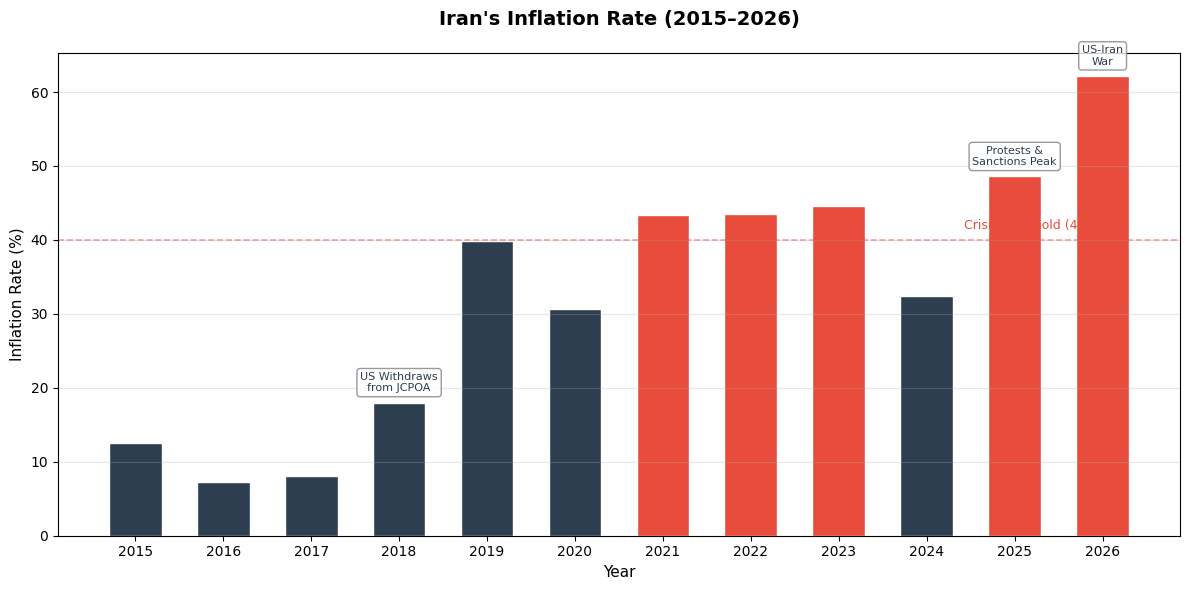

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#e74c3c' if float(val) >= 40 else '#2c3e50' for val in df_full['inflation']]

bars = ax.bar(df_full.index, df_full['inflation'], color=colors, width=0.6, edgecolor='white')

ax.axhline(40, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.5)
ax.text(df_full.index[-1], 41.5, 'Crisis threshold (40%)', color='#e74c3c', fontsize=9, ha='right')

events = {
    '2018': 'US Withdraws\nfrom JCPOA',
    '2025': 'Protests &\nSanctions Peak',
    '2026': 'US-Iran\nWar'
}

for year, label in events.items():
    if year in df_full.index:
        val = df_full.loc[year, 'inflation']
        ax.text(year, val + 1.5, label, ha='center', fontsize=8, color='#2c3e50',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

ax.set_title("Iran's Inflation Rate (2015–2026)", fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Inflation Rate (%)', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/02_iran_inflation.png', dpi=150, bbox_inches='tight')
plt.show()

## Sources
- 2015–2024: World Bank, Inflation, consumer prices (FP.CPI.TOTL.ZG), Iran
- 2025: IMF World Economic Outlook estimate (October 2025)
- 2026: February 2026 y-o-y snapshot, World Bank Iran MPO Report (March 2026)

**Note:** 2025 is an IMF estimate pending official release. 
2026 reflects a February snapshot, not a full-year average.